In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Path to dataset files: /kaggle/input/housing-prices-dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

df=pd.read_csv("/kaggle/input/housing-prices-dataset/Housing.csv")
print(df.head(5))

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [ ]:
from itertools import dropwhile
x=df[['area','bedrooms','bathrooms','stories','parking']]
y=df['price']
x=pd.get_dummies(x,drop_first=True)


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
model.intercept_
model.coef_[0]

np.float64(308.86695608764126)

In [ ]:
y_predict=model.predict(x_test)

Accuracy metrics


In [ ]:
print(mean_squared_error(y_test,y_predict))
print(mean_absolute_error(y_test,y_predict))
print(r2_score(y_test,y_predict))
print(np.sqrt(mean_squared_error(y_test,y_predict)))

2292721545725.3623
1127483.352323519
0.5464062355495871
1514173.5520492233


Regression Line

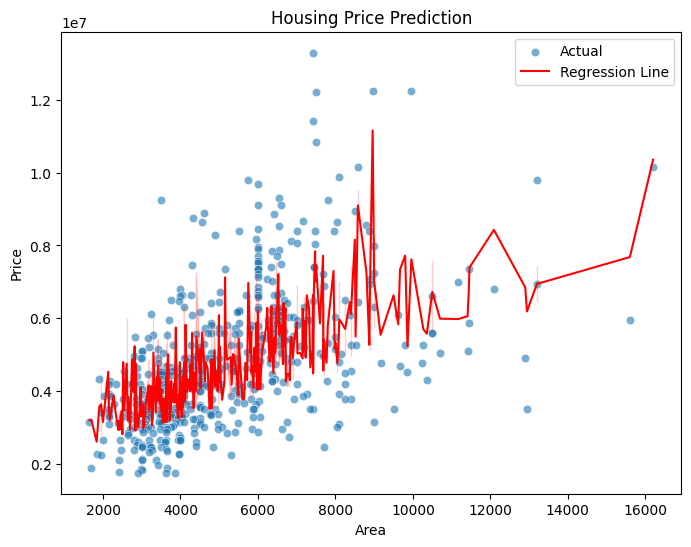

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['area'], y=df['price'], alpha=0.6, label="Actual")
sns.lineplot(x=df['area'], y=model.predict(pd.get_dummies(df[['area','bedrooms','bathrooms','stories','parking']], drop_first=True)),
             color='red', label="Regression Line")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Housing Price Prediction")
plt.legend()
plt.show()


Q)What is regression?
Ans)Regression is a statistical method used to understand and quantify the relationship between a dependent variable and one or more independent variables. It helps in prediction, trend anlysis, and identifying how chages in inputs affect outputs.

Q)Difference between regression and classification?
Ans)- Regression is about predicting a number. It answers questions like “How much?” or “What value?”. Ex: predicting the price of a house based on its area, bedrooms, and location. The output is continuous, it could be any number within a range.
- Classification is about predicting a category. It answers questions like “Which type?” or “Yes or No?”.Ex: predicting whether a house is Luxury or Affordable. The output is discrete, it belongs to a fixed set of labels.



Q)What is dependent variable?
Ans)A dependent variable is the outcome you are trying to explain or predict in an analysis. It’s called dependant because its value depends on changes in one or more other variables.


Q)What is overfitting?
Ans)Overfitting happens when a machine learning model learns the training data too closely including noise and random patterns, so it performs very well on the training set but poorly on new, unseen data. The model memorizes instead of generalizing.

Q)Explain regression line?
Ans)A regression line is the straight line that best represents the relationship between two variables in a regression analysis. It’s the line that minimizes the difference between the actual data points and the predicted values from the model.
